## BA 6-74061 (2026 Spring) Assignment 1: Neural Networks
## Myung Cho

In [1]:
# Library
import os
import json
import random
from dataclasses import dataclass, asdict
from typing import List, Optional, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, regularizers
from tensorflow.keras.datasets import imdb

try:
    from IPython.display import display 
except Exception:
    display = None

In [2]:
# 1) Setup
def set_seed(seed: int = 42) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


In [3]:
# 2) IMDB Data
def vectorize_sequences(sequences: List[List[int]], dimension: int = 10000) -> np.ndarray:
    """Multi-hot encode IMDB integer sequences into 0/1 vectors."""
    results = np.zeros((len(sequences), dimension), dtype=np.float32)
    for i, seq in enumerate(sequences):
        results[i, seq] = 1.0
    return results


def load_imdb(num_words: int = 10000) -> Dict[str, np.ndarray]:
    (train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=num_words)

    x_train = vectorize_sequences(train_data, dimension=num_words)
    x_test = vectorize_sequences(test_data, dimension=num_words)

    y_train = np.asarray(train_labels).astype("float32")
    y_test = np.asarray(test_labels).astype("float32")

    return {
        "x_train": x_train,
        "y_train": y_train,
        "x_test": x_test,
        "y_test": y_test,
        "num_words": num_words
    }

In [4]:
# 3) Model builder (experiments setting)
@dataclass
class ExperimentConfig:
    exp_name: str
    n_hidden_layers: int = 2
    hidden_units: int = 16
    activation: str = "relu"              
    loss: str = "binary_crossentropy"     
    optimizer: str = "rmsprop"
    learning_rate: Optional[float] = None 
    dropout_rate: float = 0.0             
    l2_lambda: float = 0.0               
    batch_size: int = 512
    epochs: int = 20
    validation_split: float = 0.2
    seed: int = 42


def build_model(cfg: ExperimentConfig, input_dim: int) -> tf.keras.Model:
    """Simple MLP for multi-hot IMDB vectors."""
    reg = regularizers.l2(cfg.l2_lambda) if cfg.l2_lambda and cfg.l2_lambda > 0 else None

    model = tf.keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    for _ in range(cfg.n_hidden_layers):
        model.add(layers.Dense(cfg.hidden_units, activation=cfg.activation, kernel_regularizer=reg))
        if cfg.dropout_rate and cfg.dropout_rate > 0:
            model.add(layers.Dropout(cfg.dropout_rate))

    model.add(layers.Dense(1, activation="sigmoid"))

    # Optimizer 
    if cfg.learning_rate is not None:
        opt_name = cfg.optimizer.lower()
        if opt_name == "rmsprop":
            opt = tf.keras.optimizers.RMSprop(learning_rate=cfg.learning_rate)
        elif opt_name == "adam":
            opt = tf.keras.optimizers.Adam(learning_rate=cfg.learning_rate)
        else:
            raise ValueError(f"Unsupported optimizer for learning_rate override: {cfg.optimizer}")
    else:
        opt = cfg.optimizer  

    model.compile(optimizer=opt, loss=cfg.loss, metrics=["accuracy"])
    return model

In [5]:
# 4) Visualization setting
def show_history(history: tf.keras.callbacks.History, title: str) -> None:
    """Show training vs validation accuracy over epochs."""
    acc = history.history.get("accuracy", [])
    val_acc = history.history.get("val_accuracy", [])

    plt.figure()
    plt.plot(range(1, len(acc) + 1), acc, label="train_accuracy")
    plt.plot(range(1, len(val_acc) + 1), val_acc, label="val_accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()
    plt.close()

In [6]:
# 5) Results
def run_experiment(cfg: ExperimentConfig, data: Dict[str, np.ndarray], verbose_fit: int = 0) -> Dict[str, Any]:
    set_seed(cfg.seed)
    model = build_model(cfg, input_dim=data["num_words"])

    history = model.fit(
        data["x_train"],
        data["y_train"],
        epochs=cfg.epochs,
        batch_size=cfg.batch_size,
        validation_split=cfg.validation_split,
        verbose=verbose_fit
    )

    test_loss, test_acc = model.evaluate(data["x_test"], data["y_test"], verbose=0)

    last_train_acc = float(history.history["accuracy"][-1])
    last_val_acc = float(history.history["val_accuracy"][-1])
    best_val_acc = float(np.max(history.history["val_accuracy"]))

    # Learning curve
    show_history(history, title=cfg.exp_name)

    return {
        **asdict(cfg),
        "last_train_acc": last_train_acc,
        "last_val_acc": last_val_acc,
        "best_val_acc": best_val_acc,
        "test_loss": float(test_loss),
        "test_acc": float(test_acc),
    }


In [7]:
# 6) Define experiments
def get_experiments() -> List[ExperimentConfig]:
    exps: List[ExperimentConfig] = []

    # Baseline
    exps.append(ExperimentConfig(
        exp_name="baseline_2layers_16_relu_bce",
        n_hidden_layers=2,
        hidden_units=16,
        activation="relu",
        loss="binary_crossentropy",
        dropout_rate=0.0,
        l2_lambda=0.0,
        epochs=20
    ))

    # (1) hidden layers: 1 and 3
    exps.append(ExperimentConfig(
        exp_name="layers_1_16_relu_bce",
        n_hidden_layers=1, hidden_units=16, activation="relu", loss="binary_crossentropy", epochs=20
    ))
    exps.append(ExperimentConfig(
        exp_name="layers_3_16_relu_bce",
        n_hidden_layers=3, hidden_units=16, activation="relu", loss="binary_crossentropy", epochs=20
    ))

    # (2) hidden units: 32, 64
    exps.append(ExperimentConfig(
        exp_name="units_32_2layers_relu_bce",
        n_hidden_layers=2, hidden_units=32, activation="relu", loss="binary_crossentropy", epochs=20
    ))
    exps.append(ExperimentConfig(
        exp_name="units_64_2layers_relu_bce",
        n_hidden_layers=2, hidden_units=64, activation="relu", loss="binary_crossentropy", epochs=20
    ))

    # (3) loss: mse
    exps.append(ExperimentConfig(
        exp_name="loss_mse_2layers_16_relu",
        n_hidden_layers=2, hidden_units=16, activation="relu", loss="mse", epochs=20
    ))

    # (4) activation: tanh
    exps.append(ExperimentConfig(
        exp_name="activation_tanh_2layers_16_bce",
        n_hidden_layers=2, hidden_units=16, activation="tanh", loss="binary_crossentropy", epochs=20
    ))

    # (5-1) Dropout
    exps.append(ExperimentConfig(
        exp_name="dropout_0p5_2layers_16_relu_bce",
        n_hidden_layers=2, hidden_units=16, activation="relu", loss="binary_crossentropy",
        dropout_rate=0.5, epochs=20
    ))

    # (5-2) Regularization (L2)
    exps.append(ExperimentConfig(
        exp_name="l2_1e-4_2layers_16_relu_bce",
        n_hidden_layers=2, hidden_units=16, activation="relu", loss="binary_crossentropy",
        l2_lambda=1e-4, epochs=20
    ))

    return exps

In [8]:
# 7) Summaries
def show_summary_table_plot(results: List[Dict[str, Any]]) -> pd.DataFrame:
    df = pd.DataFrame(results)
    
    preferred_cols = [
        "exp_name",
        "n_hidden_layers", "hidden_units", "activation", "loss",
        "dropout_rate", "l2_lambda",
        "batch_size", "epochs",
        "last_train_acc", "last_val_acc", "best_val_acc", "test_acc"
    ]
    cols = [c for c in preferred_cols if c in df.columns]

    df_summary = df[cols].sort_values("best_val_acc", ascending=False).reset_index(drop=True)
    
    if display is not None:
        display(df_summary)
    else:
        print(df_summary.to_string(index=False))

    # Plots: best validation accuracy by experiment
    plt.figure(figsize=(10, 4))
    plt.bar(
    df_summary["exp_name"],
    df_summary["best_val_acc"]
    ) 
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Best Validation Accuracy") 
    plt.ylim(0.86, 0.90)
    yticks = np.arange(0.86, 0.901, 0.005)
    plt.yticks(yticks, [f"{y:.3f}" for y in yticks])  
    plt.title("IMDB Hyperparameter Tuning Summary (Best Val Acc, Zoomed)")
    plt.tight_layout()
    plt.show()

    return df_summary



Running: baseline_2layers_16_relu_bce


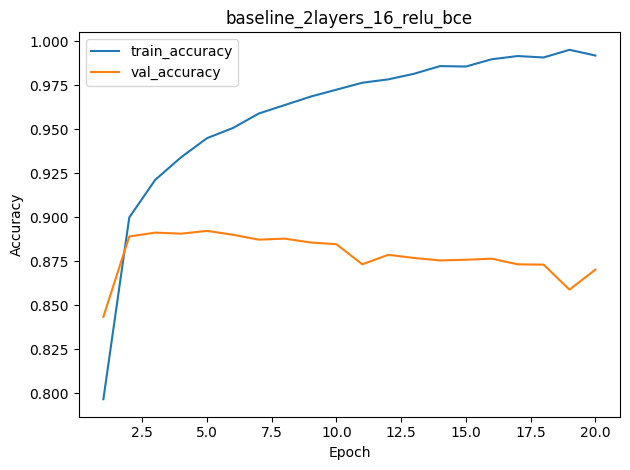


Running: layers_1_16_relu_bce


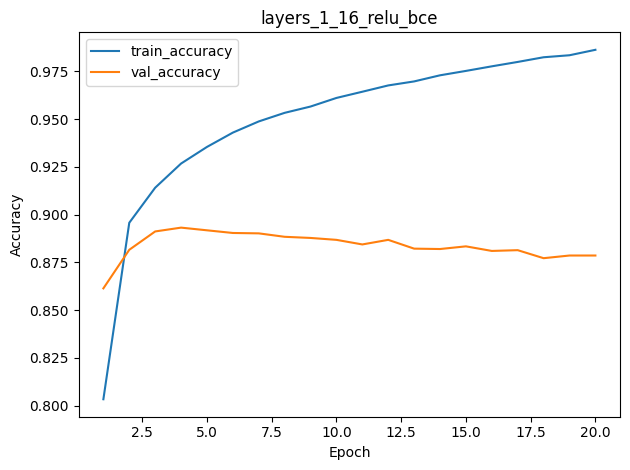


Running: layers_3_16_relu_bce


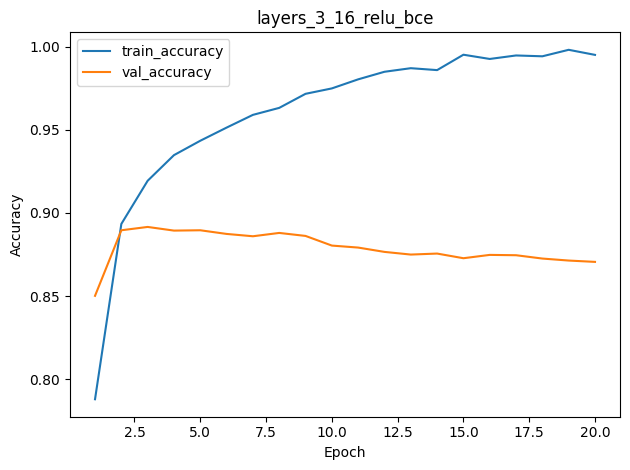


Running: units_32_2layers_relu_bce


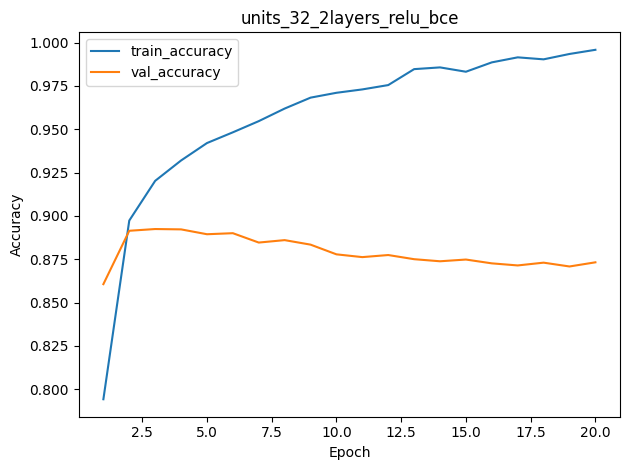


Running: units_64_2layers_relu_bce


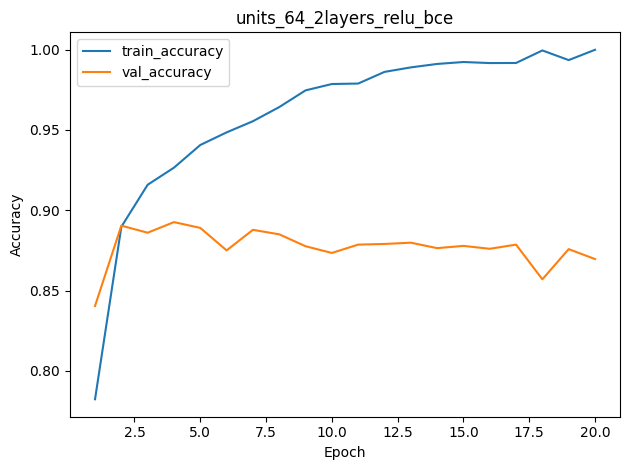


Running: loss_mse_2layers_16_relu


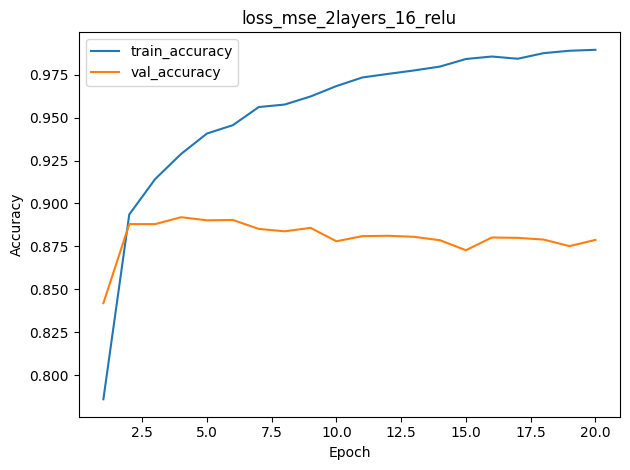


Running: activation_tanh_2layers_16_bce


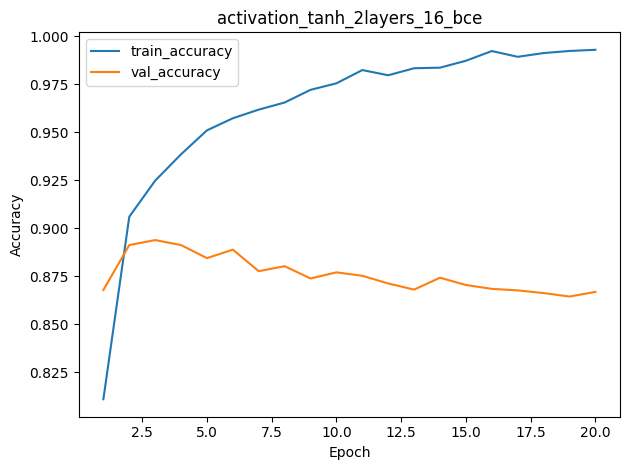


Running: dropout_0p5_2layers_16_relu_bce


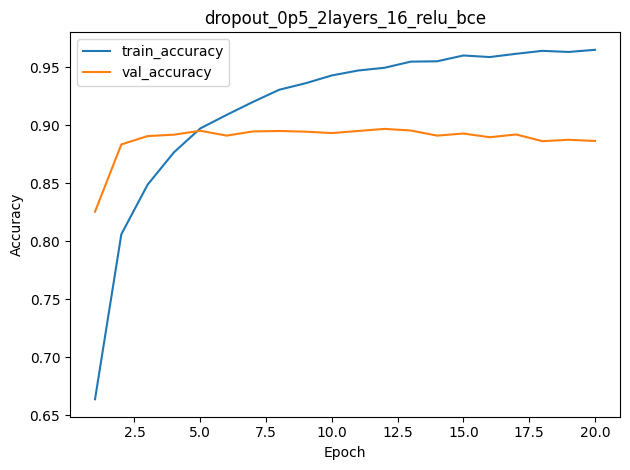


Running: l2_1e-4_2layers_16_relu_bce


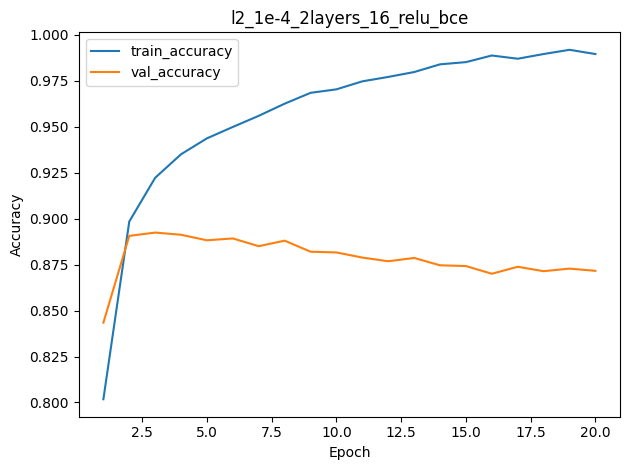

,exp_name,n_hidden_layers,hidden_units,activation,loss,dropout_rate,l2_lambda,batch_size,epochs,last_train_acc,last_val_acc,best_val_acc,test_acc
0,dropout_0p5_2layers_16_relu_bce,2,16,relu,binary_crossentropy,0.5,0.0000,512,20,0.96520,0.8866,0.8970,0.87744
1,activation_tanh_2layers_16_bce,2,16,tanh,binary_crossentropy,0.0,0.0000,512,20,0.99290,0.8668,0.8938,0.84916
2,layers_1_16_relu_bce,1,16,relu,binary_crossentropy,0.0,0.0000,512,20,0.98630,0.8786,0.8932,0.86664
3,units_64_2layers_relu_bce,2,64,relu,binary_crossentropy,0.0,0.0000,512,20,0.99985,0.8696,0.8926,0.85420
4,l2_1e-4_2layers_16_relu_bce,2,16,relu,binary_crossentropy,0.0,0.0001,512,20,0.98950,0.8716,0.8924,0.85940
5,units_32_2layers_relu_bce,2,32,relu,binary_crossentropy,0.0,0.0000,512,20,0.99580,0.8732,0.8924,0.85688
6,baseline_2layers_16_relu_bce,2,16,relu,binary_crossentropy,0.0,0.0000,512,20,0.99180,0.8702,0.8922,0.85736
7,loss_mse_2layers_16_relu,2,16,relu,mse,0.0,0.0000,512,20,0.98940,0.8788,0.8920,0.86644
8,layers_3_16_relu_bce,3,16,relu,binary_crossentropy,0.0,0.0000,512,20,0.99500,0.8706,0.8916,0.85708


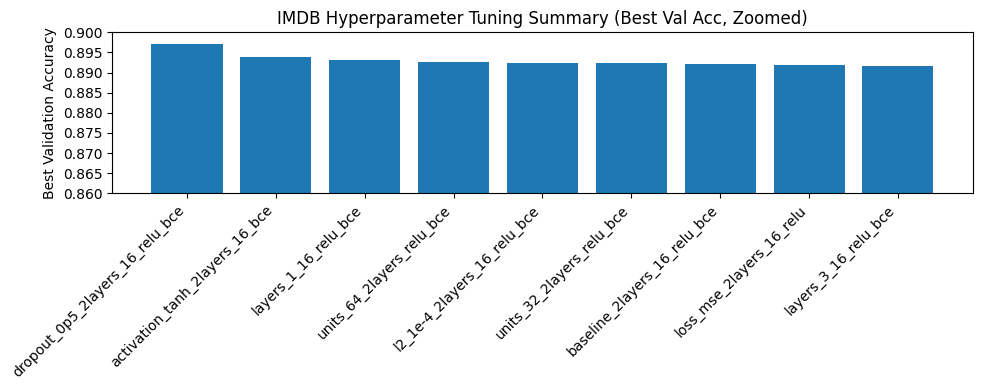


My final pick (by best_val_acc):
- dropout_0p5_2layers_16_relu_bce | best_val_acc=0.8970 | test_acc=0.8774 | layers=2 | units=16 | activation=relu | loss=binary_crossentropy | dropout=0.5 | l2=0.0


In [9]:
# 8) Main
def main() -> None:
    data = load_imdb(num_words=10000)

    results: List[Dict[str, Any]] = []
    for cfg in get_experiments():
        print(f"\nRunning: {cfg.exp_name}")
        res = run_experiment(cfg, data, verbose_fit=0)
        results.append(res)

    df_summary = show_summary_table_plot(results)

    # Final Conclusion
    best = df_summary.iloc[0]
    print("\nMy final pick (by best_val_acc):")
    print(
        f"- {best['exp_name']} | best_val_acc={best['best_val_acc']:.4f} | "
        f"test_acc={best['test_acc']:.4f} | layers={best['n_hidden_layers']} | "
        f"units={best['hidden_units']} | activation={best['activation']} | loss={best['loss']} | "
        f"dropout={best['dropout_rate']} | l2={best['l2_lambda']}"
    )


if __name__ == "__main__":
    main()